In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy import stats
import statsmodels.api as sm

In [2]:
sys.path.append("C:/Users/MSI Modern/Downloads/Google_Advanced_Data_Analytics_Professional/KevinVChin/4-The_Power_of_Statistics/1-Module/3-Calculate_statistics_with_Python/education_districtwise.csv")

#JupyterNotebook和Python要读取指定本地文件夹方法，只需在代码前增加两行代码：
#import sys
#sys.path.append(D：工作文件) #换成目标路径即可。
#Credit: https://blog.csdn.net/weixin_42508806/article/details/126398690

In [33]:
education_districtwise= pd.read_csv("C:/Users/MSI Modern/Downloads/Google_Advanced_Data_Analytics_Professional/KevinVChin/4-The_Power_of_Statistics/1-Module/3-Calculate_statistics_with_Python/education_districtwise.csv")

education_districtwise.head(10)
#Read dataset

,DISTNAME,STATNAME,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,OVERALL_LI
0,DISTRICT32,STATE1,13,391,104,875564.0,66.92
1,DISTRICT649,STATE1,18,678,144,1015503.0,66.93
2,DISTRICT229,STATE1,8,94,65,1269751.0,71.21
3,DISTRICT259,STATE1,13,523,104,735753.0,57.98
4,DISTRICT486,STATE1,8,359,64,570060.0,65.00
5,DISTRICT323,STATE1,12,523,96,1070144.0,64.32
6,DISTRICT114,STATE1,6,110,49,147104.0,80.48
7,DISTRICT438,STATE1,7,134,54,143388.0,74.49
8,DISTRICT610,STATE1,10,388,80,409576.0,65.97
9,DISTRICT476,STATE1,11,361,86,555357.0,69.90


In [4]:
education_districtwise.describe()

,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,OVERALL_LI
count,680.000000,680.000000,680.000000,6.340000e+02,634.000000
mean,10.760294,874.614706,121.226471,1.899024e+06,73.395189
std,9.585360,622.711657,94.040172,1.547475e+06,10.098460
min,1.000000,6.000000,1.000000,7.948000e+03,37.220000
25%,5.000000,390.750000,56.750000,8.226940e+05,66.437500
50%,8.000000,785.500000,101.000000,1.564392e+06,73.490000
75%,13.000000,1204.250000,162.500000,2.587520e+06,80.815000
max,66.000000,3963.000000,592.000000,1.105413e+07,98.760000


In [5]:
education_districtwise['OVERALL_LI'].describe()

#Use Mean to oberve which area is over/under average

count    634.000000
mean      73.395189
std       10.098460
min       37.220000
25%       66.437500
50%       73.490000
75%       80.815000
max       98.760000
Name: OVERALL_LI, dtype: float64

In [6]:
education_districtwise['STATNAME'].describe()

#Use describe(), to see which state have the most district
#Unique= State only with one observation
#Top= State only with most observation
#Freq= Mode(Top occurs times)

count         680
unique         36
top       STATE21
freq           75
Name: STATNAME, dtype: object

In [7]:
range_overall_li= education_districtwise['OVERALL_LI'].max()- education_districtwise['OVERALL_LI'].min()
range_overall_li

#Calculate the range of 'OVERALL_LI', = Max value- Min value

61.540000000000006

<Axes: >

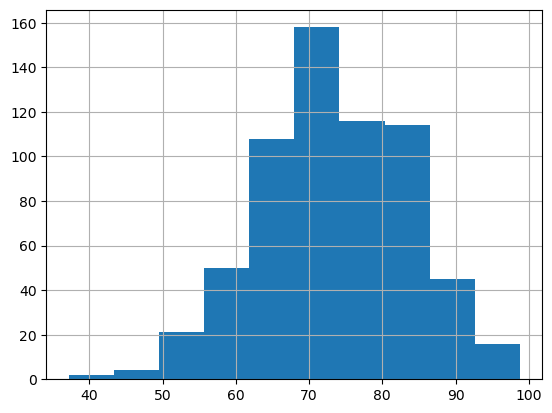

In [8]:
#To find out if the data fits a specific type of probability distribution
#Plot Histogram, to determine if it resembles the shape of a specific distribution

education_districtwise['OVERALL_LI'].hist()

In [9]:
#Using the Empirical rules here

mean_overall_li= education_districtwise['OVERALL_LI'].mean()
mean_overall_li

73.39518927444796

In [10]:
std_overall_li= education_districtwise['OVERALL_LI'].std()
std_overall_li

10.098460413782469

In [21]:
upper_limit= mean_overall_li + 1 * std_overall_li
lower_limit= mean_overall_li - 1 * std_overall_li #1 here refer to +- Std from the mean, can be change to check according to Empirical rules
((education_districtwise['OVERALL_LI']>=lower_limit) & (education_districtwise['OVERALL_LI']<= upper_limit)).mean()

0.6191176470588236

In [23]:
#Find Z-Score= Measure of how many Std below or above the population mean a data points is
#Use Z-Score to measure the relative position of the value and find outliers in the data 

education_districtwise['Z_SCORE']= stats.zscore(education_districtwise['OVERALL_LI'])
education_districtwise

,DISTNAME,STATNAME,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,OVERALL_LI,Z_SCORE
0,DISTRICT32,STATE1,13,391,104,875564.0,66.92,NaN
1,DISTRICT649,STATE1,18,678,144,1015503.0,66.93,NaN
2,DISTRICT229,STATE1,8,94,65,1269751.0,71.21,NaN
3,DISTRICT259,STATE1,13,523,104,735753.0,57.98,NaN
4,DISTRICT486,STATE1,8,359,64,570060.0,65.00,NaN
...,...,...,...,...,...,...,...,...
675,DISTRICT522,STATE29,37,876,137,5296396.0,78.05,NaN
676,DISTRICT498,STATE29,64,1458,230,4042191.0,56.06,NaN
677,DISTRICT343,STATE29,59,1117,216,3483648.0,65.05,NaN
678,DISTRICT130,STATE29,51,993,211,3522644.0,66.16,NaN


In [109]:
education_districtwise[(education_districtwise['Z_SCORE']>1)|(education_districtwise['Z_SCORE']<-1)]

#'|'= Or

,DISTNAME,STATNAME,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,OVERALL_LI,Z_SCORE


In [110]:
#Simulate random sampling and choose the desired sample size
#Use the .sample(n, replace, random_state) function in pandas
#n= refers to the desired sample size
#replace= whether you are sampling with or without replacement 
##Sampling with replacement= when a population element can be elected more than one time, Sampling without replacement= when a population element can be selected only one time
###Exp: No.1-100, one number can only used once= Sampling without replacement
#random_state= the seed of the random number
##Random seed= A starting point for generating random numbers 

In [111]:
sampled_data= education_districtwise.sample(n=50, replace= True, random_state= 31208)
sampled_data

#replace= True= Sampling with replacement
#random_state= 31208= Arbitrary number

,DISTNAME,STATNAME,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,OVERALL_LI,Z_SCORE
615,DISTRICT606,STATE20,6,782,96,NaN,NaN,NaN
210,DISTRICT618,STATE28,5,183,34,656916.0,56.00,NaN
348,DISTRICT255,STATE34,10,920,78,1670931.0,73.86,NaN
248,DISTRICT63,STATE18,8,230,32,146742.0,82.06,NaN
276,DISTRICT57,STATE27,6,121,6,270063.0,85.58,NaN
350,DISTRICT254,STATE34,33,3142,286,7102430.0,67.53,NaN
252,DISTRICT194,STATE3,8,271,24,78413.0,62.48,NaN
10,DISTRICT412,STATE1,11,187,95,476820.0,68.69,NaN
478,DISTRICT155,STATE22,5,1116,58,1311008.0,71.11,NaN
638,DISTRICT609,STATE6,18,1470,167,2468965.0,74.72,NaN


In [112]:
#Calculate Mean for the sample data

estimate1= sampled_data['OVERALL_LI'].mean()
estimate1

74.37808510638298

In [113]:
estimate2= education_districtwise['OVERALL_LI'].sample(n=50, replace= True, random_state= 56810).mean()
estimate2

75.06804347826088

In [114]:
#Use for loop to run the sampling distribution

estimate_list= []
for i in range(10000):
    estimate_list.append(education_districtwise['OVERALL_LI'].sample(n=50, replace= True).mean())
estimated_df= pd.DataFrame(data={'estimate': estimate_list})

estimated_df

#estimated_df= pd.DataFrame(data={'estimate': estimate_list})
#pd.DataFrame= create a DataFrame
#data={'estimate': estimate_list}: 'estimate' will become the column name in the DataFrame, estimate_list is a Python list containing the data that will populate the rows of the column named 'estimate'

,estimate
0,74.462041
1,74.127778
2,74.976889
3,73.844468
4,75.013542
...,...
9995,71.309302
9996,73.762000
9997,73.954800
9998,74.585745


In [115]:
 mean_sample_means= estimated_df['estimate'].mean()
mean_sample_means

73.39484327691865

In [116]:
#Python in construct confidence interval 

#Use the Var=sampled_data, used before this 
#Scipy function= stats.norm.interval(alpha, loc, scale)    
#alpha= confidence interval 
#loc= sample mean
#scale= sample standard error

sample_mean= sampled_data['OVERALL_LI'].mean()
sample_mean

74.37808510638298

In [117]:
estimated_standard_error= sampled_data['OVERALL_LI'].std()/np.sqrt(sampled_data.shape[0])
estimated_standard_error

#Find the Std 1st, then/ square root of the sample 

1.350104621978153

In [118]:
#With all the above info, to construct the confidence interval

stats.norm.interval(confidence=0.95, loc= sample_mean, scale=estimated_standard_error)

#stats.norm.interval(confidence/alpha=0.95, loc= sample_mean, scale=estimated_standard_error)
#alpha= confidence in different version

(71.73192867194474, 77.02424154082122)

In [119]:
stats.norm.interval(confidence=0.99, loc= sample_mean, scale=estimated_standard_error)

(70.90044605823485, 77.85572415453112)

In [37]:
education_districtwise= education_districtwise.dropna()
state21= education_districtwise[education_districtwise['STATNAME']=='STATE21']
state28= education_districtwise[education_districtwise['STATNAME']=='STATE28']

sampled_state21= state21.sample(n=20, random_state= 13490, replace= True)
sampled_state28= state28.sample(n=20, random_state= 39100, replace= True)

In [39]:
sampled_state21['OVERALL_LI'].mean()

70.82900000000001

In [41]:
sampled_state28['OVERALL_LI'].mean()

64.619

In [43]:
sampled_state21['OVERALL_LI'].mean()- sampled_state28['OVERALL_LI'].mean()

6.210000000000008

In [ ]:
##Hypothesis
#Null: There is no difference in the mean district literacy rates between State 21 and Sate 28 
#Alternative: There is a difference in the mean district literacy rates between State 21 and Sate 28 

#Significance level
##5%/0.05

#P-Value
#stats.ttest_ind(a, b, equal_var), for 2 smaple T-test, use this Scipy function
#a= observation from the 1st sample 
#b= observation from the 2nd sample 
#equal_var= indicates whether the population variance of the 2 sample is assumed to be equal(True/False)

In [45]:
stats.ttest_ind(a=sampled_state21['OVERALL_LI'], b=sampled_state28['OVERALL_LI'], equal_var=False)

TtestResult(statistic=3.2089039903662018, pvalue=0.0027284949553879577, df=37.511574254104644)

In [47]:
#Conclusion,

#If P-Value< Significance level: reject the Null Hypothesis 
#Statistically significant difference in literacy rates

#If P-Value> Significance level: fail to reject the Null Hypothesis 
#No statistically significant difference in literacy rates